# Tutorial: Cell-Type Prioritization for GWAS Traits using CELLECT
This tutorial describes the integration of Genome-Wide Association Studies (GWAS) data with single-cell genomics to identify disease-relevant cell types using the CELLECT (Cell-type ELection intermediate) framework. The analytical workflow is divided into two essential steps, starting with CELLEX (Cell-type Expression Specificity), which is used to create robust cell-type specificity profiles, known as ESmu scores, from single-cell RNA sequencing data. In the subsequent step, CELLECT-MAGMA, these specificity profiles are statistically linked to GWAS summary statistics via a linear regression model, allowing for the prioritization of those cell types that significantly influence the genetic association. This methodological approach enables the discovery of biological tissues and cell populations that are likely involved in the development of complex traits and diseases. To perform the prioritization in Python, ensure that the cellex and statsmodels packages are installed.

CELLECT publication: Pascal N Timshel, Jonatan J Thompson, Tune H Pers (2020) Genetic mapping of etiologic brain cell types for obesity eLife 9:e55851 https://doi.org/10.7554/eLife.55851

## Setup

In [1]:
import numpy as np
np.float = float
np.int = int
np.bool = bool
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numba
numba.set_num_threads(1)
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
import matplotlib.pyplot as plt
from plotnine import *
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

from cellink.resources import get_dummy_onek1k, get_gwas_catalog_study_summary_stats
from cellink.tl.external import run_magma_pipeline, run_cellex, run_cellect_prioritization

/lustre/groups/ml01/workspace/leonard.sima/envs/cellink7/lib/python3.11/site-packages/sgkit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
dd = get_dummy_onek1k(
    config_path="../../src/cellink/resources/config/dummy_onek1k.yaml",
    verify_checksum=False
)
dd.G.obs["donor_id"] = dd.G.obs.index

print(f"Dataset shape: {dd.shape}")
print(f"Cell types: {dd.C.obs['predicted.celltype.l2'].unique()[:5]}")

[2026-05-10 17:36:48,568] INFO:root: /home/icb/leonard.sima/cellink_data/dummy_onek1k/dummy_onek1k.dd.h5 already exists
[2026-05-10 17:36:48,569] WARNING:root: No checksum provided, skipping verification


[2026-05-10 17:36:54,144] INFO:root: Loaded dummy OneK1K dataset: (100, 146939, 125366, 34073)
Dataset shape: (100, 146939, 125366, 34073)
Cell types: ['gdT', 'NK', 'CD8 TEM', 'CD4 Naive', 'CD4 TCM']
Categories (31, object): ['ASDC', 'B intermediate', 'B memory', 'B naive', ..., 'cDC2', 'dnT', 'gdT', 'pDC']


We filter the DonorData object to speed-up the computation for demonstration purposes.

In [3]:
celltype_counts = dd.C.obs["predicted.celltype.l2"].value_counts()
celltypes_of_interest = celltype_counts[celltype_counts > 100].index
dd.C = dd.C[
    dd.C.obs["predicted.celltype.l2"].isin(celltypes_of_interest)
].copy()
dd.C = dd.C[:, dd.C.var["vst.variable"] == 1].copy()

We utilize a publicly available GWAS summary statistic, here for iunstance for Type 2 Diabetes.

In [4]:
gwas_df = get_gwas_catalog_study_summary_stats("GCST90018926", genome_build="GRCh37")
gwas_df

[2026-05-10 17:36:56,962] INFO:root: Fetching https://www.ebi.ac.uk/gwas/rest/api/v2/studies/GCST90018926
[2026-05-10 17:36:57,434] INFO:root: User requested GRCh37, skipping harmonised files and searching base directory
[2026-05-10 17:36:57,601] INFO:root: Selected file matching requested build GRCh37: GCST90018926_buildGRCh37.tsv.gz
[2026-05-10 17:36:57,603] INFO:root: Using build-specific summary statistics (build: GRCh37)
[2026-05-10 17:36:57,606] INFO:root: Downloading http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST90018001-GCST90019000/GCST90018926/GCST90018926_buildGRCh37.tsv.gz to /home/icb/leonard.sima/cellink_data/GCST90018926_summary_stats.tsv.gz


,chromosome,base_pair_location,effect_allele,other_allele,effect_allele_frequency,beta,standard_error,p_value,variant_id
0,1,100000012,T,G,0.280989,-0.0146,0.0068,0.03234,NaN
1,1,10000006,A,G,0.005652,0.0336,0.0561,0.54980,NaN
2,1,100000135,T,A,0.001687,-0.0276,0.1122,0.80540,NaN
3,1,100000374,C,G,0.000579,0.2396,0.1991,0.22880,NaN
4,1,100000827,T,C,0.332151,-0.0148,0.0065,0.02345,NaN
...,...,...,...,...,...,...,...,...,...
25845086,X,99998829,T,C,0.439544,-0.0103,0.0050,0.03884,NaN
25845087,X,99999212,CT,C,0.542889,0.0157,0.0087,0.07114,NaN
25845088,X,99999349,A,G,0.551784,0.0102,0.0050,0.03944,NaN
25845089,X,9999977,A,G,0.001073,-0.3525,0.1717,0.04007,NaN


We convert the public GWAS statistic to gene-level statistics using MAGMA. MAGMA needs to be downloaded as shown below:

In [5]:
import requests, zipfile, io, os, stat

url = "https://vu.data.surf.nl/public.php/dav/files/1M1d9vHtVidEwvU/?accept=zip"
url = "https://vu.data.surf.nl/public.php/dav/files/zkKbNeNOZAhFXZB/?accept=zip"

r = requests.get(url)
r.raise_for_status() 

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("magma")

for root, dirs, files in os.walk("magma"):
    for file in files:
        path = os.path.join(root, file)
        st = os.stat(path)
        os.chmod(path, st.st_mode | stat.S_IEXEC) 

In [6]:
custom_mapping = {
    "chromosome": "CHR",
    "base_pair_location": "BP",
    "p_value": "P",
}

magma_file = run_magma_pipeline(
    gwas_df,
    col_mapping=custom_mapping,
    n_samples=667504,
    magma_bin="./magma/magma",
    genome_build="GRCh37",
    gene_id_type="ensembl",
    config_file="../../configs/magma.yaml",
    ld_source="dd_genotypes",
    dd=dd,
)

[2026-05-10 17:37:31,593] INFO:cellink.tl.external._magma: Starting MAGMA pipeline (ld_source='dd_genotypes')
[2026-05-10 17:37:31,594] INFO:cellink.tl.external._magma: Downloading/checking gene location file
[2026-05-10 17:37:31,652] INFO:cellink.tl.external._magma: Using cached gene location file: /home/icb/leonard.sima/cellink_data/magma_references/NCBI37.3.gene.loc
[2026-05-10 17:37:31,713] INFO:cellink.tl.external._magma: Using cached converted gene location file: /home/icb/leonard.sima/cellink_data/magma_references/GRCh37_ensembl.gene.loc
[2026-05-10 17:38:35,112] INFO:cellink.tl.external._magma: Created SNP location file: magma_results.snp_loc.txt
[2026-05-10 17:39:11,924] INFO:cellink.tl.external._magma: Created p-value file: magma_results.p_val.txt
[2026-05-10 17:39:11,925] INFO:cellink.tl.external._magma: Exporting DonorData genotypes to PLINK format for LD reference
[2026-05-10 17:39:12,225] INFO:cellink.tl.external._magma: Exporting 137268 common variants (MAF > 0.01) out o

Writing BED: 100%|██████████| 1/1 [00:00<00:00,  3.20it/s]

Writing FAM... done.
Writing BIM... 

done.
[2026-05-10 17:39:13,896] INFO:cellink.tl.external._magma: Created PLINK files: magma_results_ld_ref.{bed,bim,fam}
[2026-05-10 17:39:14,577] INFO:cellink.tl.external._magma: Running MAGMA SNP annotation
[2026-05-10 17:39:14,577] INFO:cellink.tl.external._magma: Running: ./magma/magma --annotate window=35,10 --snp-loc magma_results.snp_loc.txt --gene-loc /home/icb/leonard.sima/cellink_data/magma_references/GRCh37_ensembl.gene.loc --out magma_results
[2026-05-10 17:40:15,638] INFO:cellink.tl.external._magma: Welcome to MAGMA v1.10 (linux)
Using flags:
	--annotate window=35,10
	--snp-loc magma_results.snp_loc.txt
	--gene-loc /home/icb/leonard.sima/cellink_data/magma_references/GRCh37_ensembl.gene.loc
	--out magma_results

Start time is 17:39:14, Sunday 10 May 2026

Starting annotation...
Reading gene locations from file /home/icb/leonard.sima/cellink_data/magma_references/GRCh37_ensembl.gene.loc... 
	adding window: 35000bp (before), 10000bp (after)
	20134 gene locations read from fi

In [7]:
# Or with a 1000G panel (no DonorData needed at all)
"""
magma_file = run_magma_pipeline(
    gwas_df,
    output_prefix="trait",
    col_mapping=custom_mapping,
    n_samples=667504,
    ld_source="reference_panel",
    reference_panel="EUR",
    genome_build="GRCh37",
    gene_id_type="ensembl",
    config_file="../../configs/magma.yaml",
    magma_bin="./magma/magma",
)
"""

# Or with your own pre-built PLINK panel
"""
magma_file = run_magma_pipeline(
    gwas_df,
    output_prefix="trait",
    col_mapping=custom_mapping,
    n_samples=667504,
    ld_source="external",
    external_ld_prefix="/data/ukbb_eur_ref",  # .bed/.bim/.fam live here
    genome_build="GRCh37",
    gene_id_type="ensembl",
    config_file="../../configs/magma.yaml",
    magma_bin="./magma/magma",
)
"""

'\nmagma_file = run_magma_pipeline(\n    gwas_df,\n    output_prefix="trait",\n    col_mapping=custom_mapping,\n    n_samples=667504,\n    ld_source="external",\n    external_ld_prefix="/data/ukbb_eur_ref",  # .bed/.bim/.fam live here\n    genome_build="GRCh37",\n    gene_id_type="ensembl",\n    config_file="../../configs/magma.yaml",\n    magma_bin="./magma/magma",\n)\n'

In [8]:
# def run_cellex(
#     adata: AnnData,
#     cell_type_col: str,
#     species: Literal["human", "mouse"] = "human",
#     map_to_human: bool = False,
#     min_genes: int = 250,
#     min_cells: int = 50,
#     prefix: str = None,
#     save_results: bool = True,
# ) -> pd.DataFrame:

esmu_file = run_cellex(
    dd.C,
    cell_type_col="predicted.celltype.l2",
    species="human",
    map_to_human=False,
    min_genes=250,
    min_cells=50,
)

[2026-05-10 17:40:24,057] INFO:cellink.tl.external._cellex: Filtering cells and genes


[2026-05-10 17:40:25,288] INFO:cellink.tl.external._cellex: Preparing data for CELLEX
[2026-05-10 17:40:25,393] INFO:cellink.tl.external._cellex: Creating CELLEX ESObject and computing ES scores
Preprocessing - checking input ... input parsed in 0 min 0 sec
Preprocessing - running remove_non_expressed ... excluded 0 / 2405 genes in 0 min 0 sec
Preprocessing - normalizing data ... data normalized in 0 min 0 sec
Preprocessing - running ANOVA ... excluded 16 / 2405 genes in 0 min 7 sec
Computing DET ... 
    esw ...
    empirical p-values ...
    esw_s ...
    finished in 0 min 1 sec
Computing EP ...
    esw ...
    empirical p-values ...
    esw_s ...
    finished in 0 min 0 sec
Computing GES ...
    esw ...
    empirical p-values ...
    esw_s ...
    finished in 0 min 1 sec
Computing NSI ...
    esw ...
    empirical p-values ...
    esw_s ...
    finished in 0 min 1 sec
Computing ESmu ...
    finished in 0 min 0 sec
Computing ESsd ...
    finished in 0 min 0 sec
Computed ['det.esw', '

In [9]:
final_results_file = run_cellect_prioritization(
    gene_results_file=magma_file,
    esmu_file=esmu_file,
    output_prefix="trait",
    exclude_mhc=True
)

[2026-05-10 17:40:37,413] INFO:cellink.tl.external._cellex: Starting CELLECT Linear Model Prioritization for 'trait'...
[2026-05-10 17:40:37,415] INFO:cellink.tl.external._cellex: Loading MAGMA results: /ictstr01/groups/ml01/workspace/leonard.sima/projects/cellink/docs/tutorials/magma_results.genes.out
[2026-05-10 17:40:37,430] INFO:cellink.tl.external._cellex: 0 MHC region genes excluded.
[2026-05-10 17:40:37,431] INFO:cellink.tl.external._cellex: Loading Expression Specificity Matrix: cellex_results.esmu.csv
[2026-05-10 17:40:37,460] INFO:cellink.tl.external._cellex: Running OLS regressions for each cell type...
[2026-05-10 17:40:38,345] INFO:cellink.tl.external._cellex: CELLECT Prioritization successful. Results saved to: trait_prioritization.csv


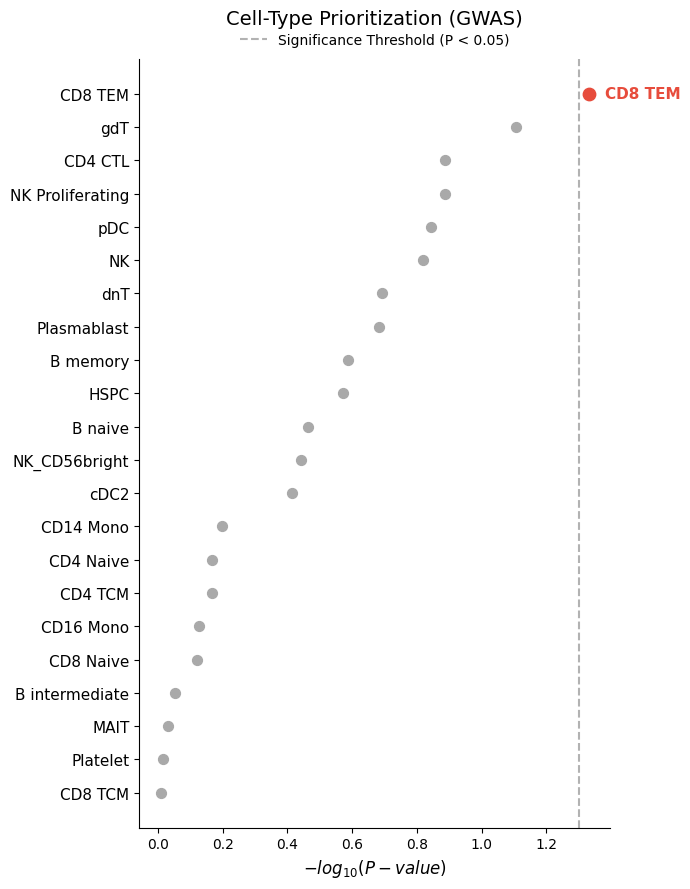

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.read_csv(final_results_file)
results_df['cell_type'] = results_df['Name'].str.replace("cellex__", "")
results_df['Coefficient_P_value'] = pd.to_numeric(results_df['Coefficient_P_value'], errors='coerce')
results_df = results_df.dropna(subset=['Coefficient_P_value'])
results_df['-log10(P)'] = -np.log10(results_df['Coefficient_P_value'] + 1e-300)

df_plot = results_df.sort_values(by='-log10(P)', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 9))

y_positions = np.arange(len(df_plot))
sig_threshold = -np.log10(0.05)
sig_idx = df_plot['-log10(P)'] > sig_threshold

ax.scatter(df_plot['-log10(P)'], y_positions, color='darkgrey', s=50, zorder=2)

if sig_idx.any():
    ax.scatter(
        df_plot.loc[sig_idx, '-log10(P)'], 
        y_positions[sig_idx], 
        color='#e74c3c', s=80, zorder=3
    )
    for idx in df_plot[sig_idx].index:
        ax.text(
            df_plot.loc[idx, '-log10(P)'] + 0.05, idx, 
            df_plot.loc[idx, 'cell_type'], 
            va='center', ha='left', fontsize=11, fontweight='bold', color='#e74c3c'
        )

line = ax.axvline(x=sig_threshold, color='grey', linestyle='--', alpha=0.6, zorder=1, label='Significance Threshold (P < 0.05)')

ax.set_yticks(y_positions)
ax.set_yticklabels(df_plot['cell_type'], fontsize=11)
ax.set_xlabel('$-log_{10}(P-value)$', fontsize=12)
ax.set_title("Cell-Type Prioritization (GWAS)", fontsize=14, pad=25)

ax.legend(handles=[line], loc='upper center', bbox_to_anchor=(0.5, 1.05), frameon=False, fontsize=10)

ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()